In [1]:
import os
# Switch to parent directory
os.chdir("..")
root = os.getcwd()

In [2]:
import sys
sys.path.insert(0, os.path.join(root, "src"))

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from spo.backtest import get_strategy, backtest, summary

returns = pd.read_parquet("data/processed/sp500_log_returns.parquet")

STRATEGIES = [
    ("equal_weight", "Equal-Weight", {}),
    ("min_variance", "Min-Variance", {}),
    ("black_litterman", "Black-Litterman", {"tau": 0.05, "risk_aversion": 2.5}),
    ("robust_mv", "Robust-MV (κ=3)", {"kappa": 3.0}),
    ("gbm_cvar", "GBM-CVaR", {"alpha": 0.95, "n_paths": 2000}),
    ("heston_cvar", "Heston-CVaR", {"alpha": 0.95, "n_paths": 2000}),
]

results = {}
for name, label, params in STRATEGIES:
    fn = get_strategy(name, **params)
    print(f"Running {label}...")
    results[label] = backtest(
        returns, fn, rebalance_freq="BME",
        lookback=504, cost=10.0,
    )

Running Equal-Weight...
Running Min-Variance...
Running Black-Litterman...
Running Robust-MV (κ=3)...
Running GBM-CVaR...
Running Heston-CVaR...


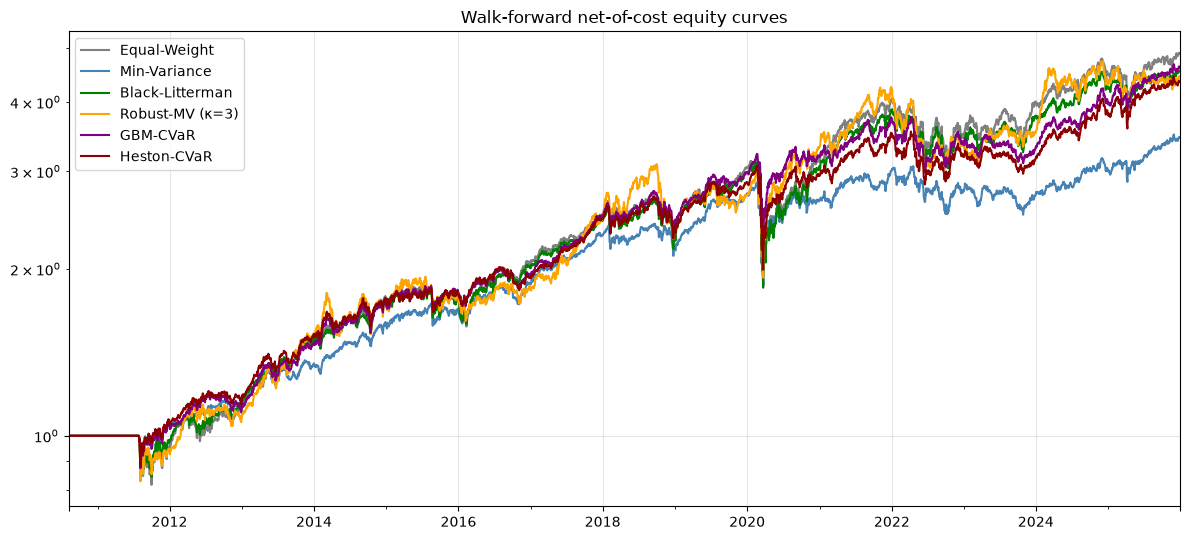

In [4]:
fig, ax = plt.subplots(figsize=(12, 5.5))
colors = ["gray", "steelblue", "green", "orange", "purple", "darkred"]
for (label, res), c in zip(results.items(), colors):
    (1 + res["net_returns"]).cumprod().plot(ax=ax, label=label, color=c, lw=1.5)
ax.set_yscale("log")
ax.set_title("Walk-forward net-of-cost equity curves")
ax.legend(loc="upper left"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [5]:
summary_table = pd.concat(
    {label: summary(res["net_returns"]) for label, res in results.items()},
    axis=1,
)
summary_table.style.format({
    "Ann. Return": "{:.2%}", "Ann. Vol": "{:.2%}",
    "Max DD": "{:.2%}", "Sharpe": "{:.2f}",
    "Sortino": "{:.2f}", "Calmar": "{:.2f}",
})

,Equal-Weight,Min-Variance,Black-Litterman,Robust-MV (κ=3),GBM-CVaR,Heston-CVaR
Ann. Returns,0.104653,0.080753,0.099607,0.097926,0.100664,0.096600
Ann. Vol,0.169727,0.119246,0.160156,0.179039,0.133305,0.133020
Sharpe,0.671986,0.711404,0.673635,0.611983,0.786637,0.760336
PSR (SR*=0),0.995623,0.996853,0.995635,0.991801,0.998866,0.998304
Sortino,0.759316,0.780354,0.754246,0.715558,0.892503,0.848580
Max DD,-0.410271,-0.350367,-0.404831,-0.376186,-0.331645,-0.349856
Calmar,0.255083,0.230481,0.246046,0.260311,0.303530,0.276113


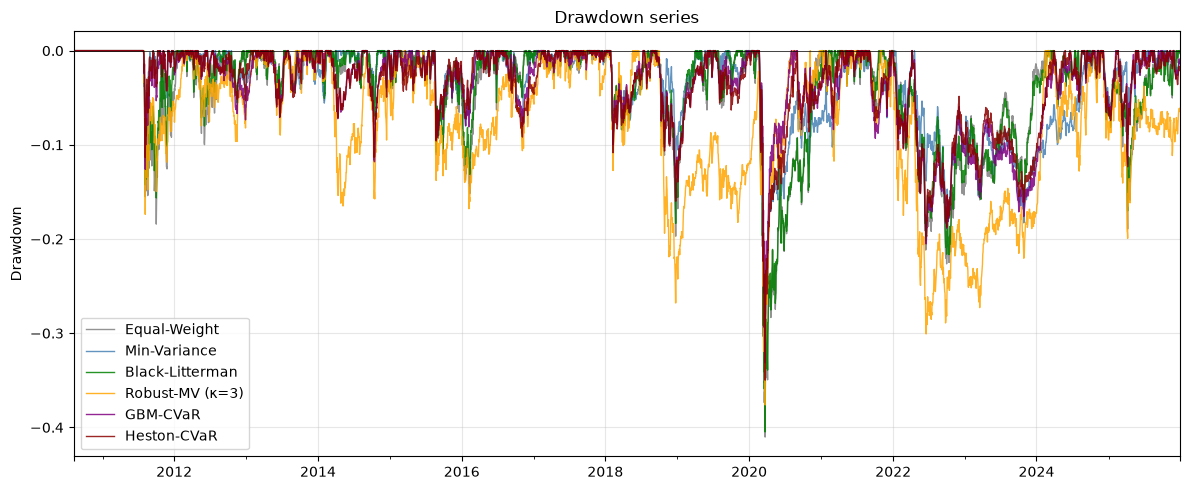

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
for (label, res), c in zip(results.items(), colors):
    cum = (1 + res["net_returns"]).cumprod()
    dd = cum / cum.cummax() - 1
    dd.plot(ax=ax, label=label, color=c, alpha=0.85, lw=1)
ax.set_title("Drawdown series")
ax.set_ylabel("Drawdown"); ax.legend(); ax.grid(alpha=0.3)
ax.axhline(0, color="black", lw=0.5)
plt.tight_layout(); plt.show()

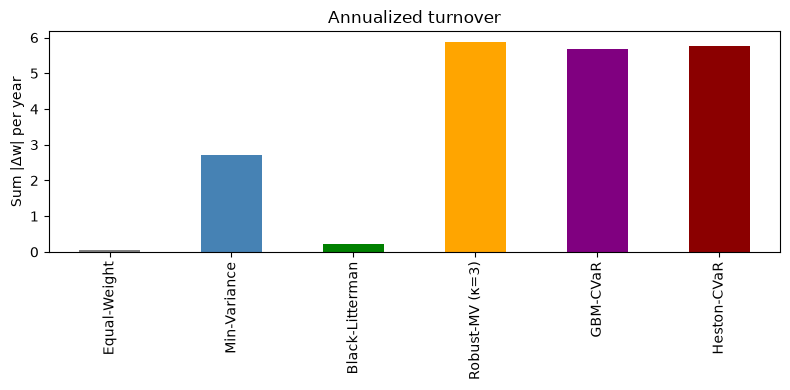

In [7]:
turnover_series = {
    label: res["turnover"] for label, res in results.items()
}
avg_turnover = pd.Series({
    label: res["turnover"].sum() / (len(res["turnover"]) / 252)
    for label, res in results.items()
})
fig, ax = plt.subplots(figsize=(8, 4))
avg_turnover.plot.bar(ax=ax, color=colors)
ax.set_title("Annualized turnover")
ax.set_ylabel("Sum |Δw| per year")
plt.tight_layout(); plt.show()